In [1]:
import numpy as np
import scipy.constants as sc
import catppuccin
import matplotlib.pyplot as plt
import adri
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/65_murmann/65pch.mat')
nmos4 = lk('lookup_table/65_murmann/65nch.mat')
#import adri as adri
#22H17
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)


## Two-Stage OTA for Switched-Capacitor Circuits

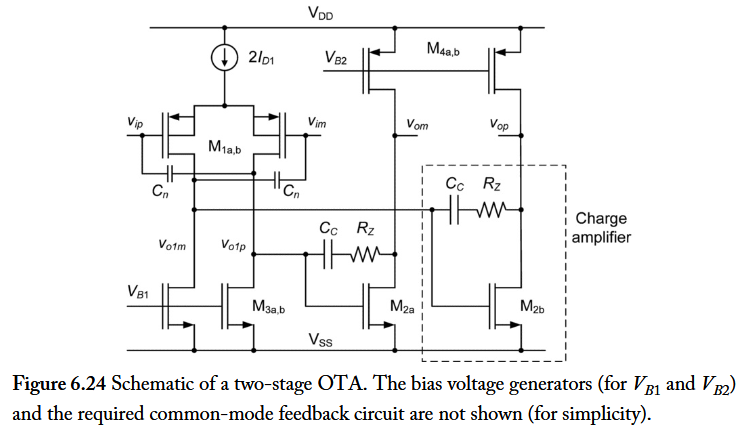

### Formulas :
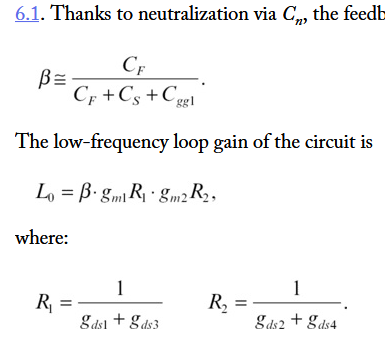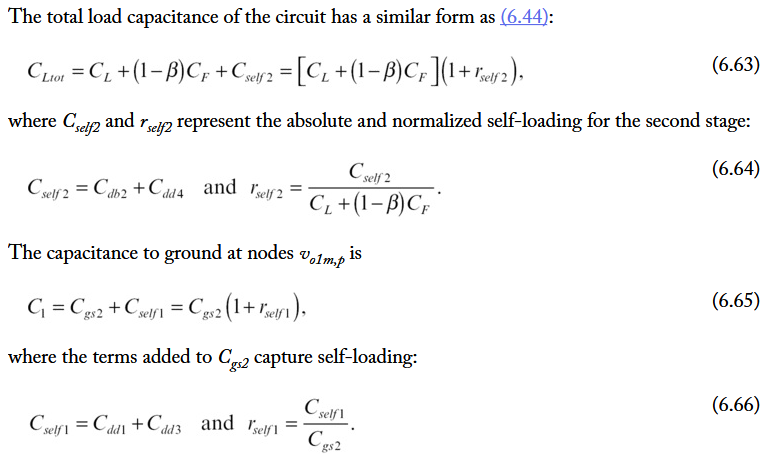  
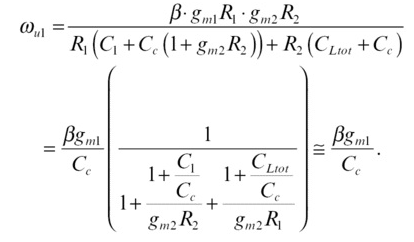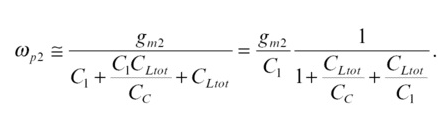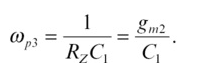  
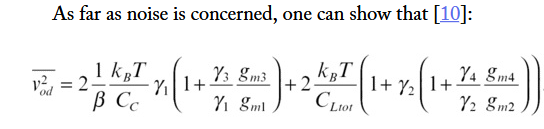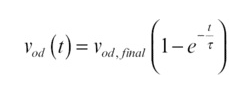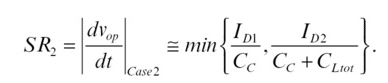  
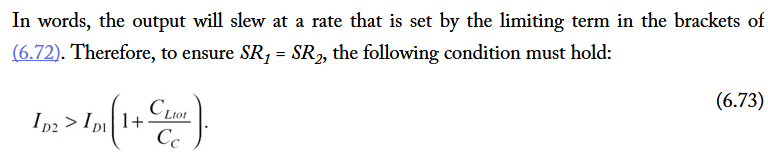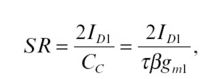  
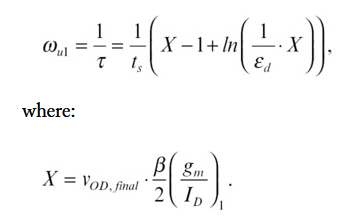

### Method :
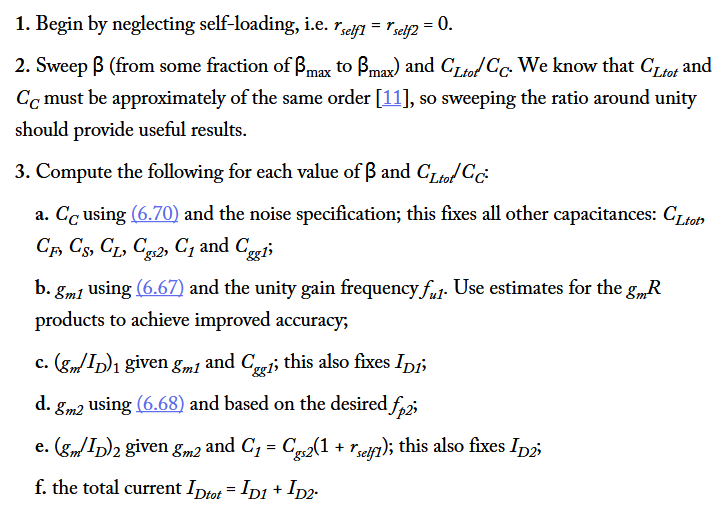  
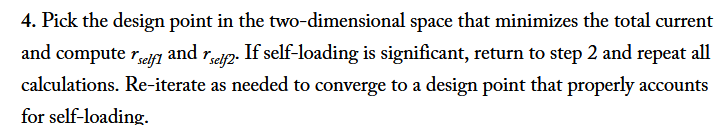

In [2]:
# #Spec
# L0 = 50
# G =2
# FO = 0.5
# vnoise = 100e-6
# ts = 5e-9

# #Param
# L14 = 0.5
# L23 = 0.8
# gm3_gm1 = 1
# gm4_gm2 = 0.5
# gamma = 0.8

cltot_cc_opt      = 0.5586
beta_opt/beta_max = 0.8310
IDtot_opt = 317.2947


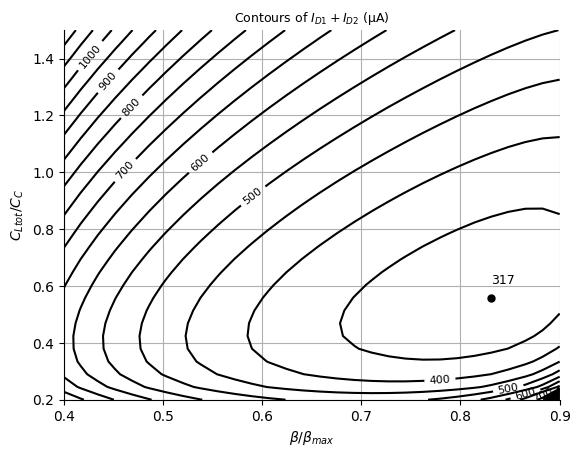

In [3]:
#Design Spec 
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 5e-9,
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.15,
    'L4': 0.15,
    'L2': 0.2,
    'L3': 0.2,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 30),
    'cltot_cc': np.linspace(0.2, 1.5, 30)
    }


def two_stage(nmos, pmos, s, d):
    kBT = 1.3806488e-23 * 300
    beta_arr     = np.atleast_1d(d['beta'])
    cltot_cc_arr = np.atleast_1d(d['cltot_cc'])
    N = len(beta_arr)   # axe 0
    M = len(cltot_cc_arr)  # axe 1
    m1 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id']}
    m2 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id','cgs','fts']}
    m3 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    m4 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    p  = {k: np.full((N, M), np.nan) for k in ['cc','cltot','cf','cs','cl','c1','rz','cn','rself1','rself2','cc_add']}
    m1['L'] = d['L1']
    m2['L'] = d['L2']
    m3['L'] = d['L3']
    m4['L'] = d['L4']

    for j, beta in enumerate(beta_arr):  # j = indice beta → ligne [j,:]
        cc    = (2/beta * kBT * d['gam1'] * (1 + d['gam3']/d['gam1'] * d['gm3_gm1'])
               + 1/cltot_cc_arr * kBT * (1 + d['gam2'] * (1 + d['gam4']/d['gam2'] * d['gm4_gm2']))
               ) / s['vod_noise']**2
        cltot = cc * cltot_cc_arr
        cf    = cltot / (1 + d['rself_2']) / (1 - beta + s['FO'] * s['G'])
        cs    = cf * s['G']
        cl    = cs * s['FO']
        cgs2  = cc * d['cgs2_cc']
        c1    = cgs2 * (1 + d['rself_1'])

        gmR    = np.sqrt(s['L0']) / beta
        gm1    = (2*np.pi * s['fu1'] * cc / beta
                  * (1 + (1 + c1/cc) / gmR + (1 + cltot/cc) / gmR))
        cgg1   = cf * (1/beta - 1 - s['G'])
        ft1    = gm1 / (2*np.pi * cgg1)
        gmid1  = pmos.lookup('GM_ID', GM_CGG=2*np.pi*ft1, L=d['L1'], WARNING=False)
        id1    = gm1 / gmid1

        gm2    = 2*np.pi * s['fp2'] * c1 * (1 + cltot/cc + cltot/c1)
        fts2   = gm2 / (2*np.pi * cgs2)
        gmid2  = nmos.lookup('GM_ID', GM_CGS=2*np.pi*fts2, L=d['L2'], WARNING=False)
        id2    = gm2 / gmid2

        # Storage [j,:] → ligne j = beta j, colonnes = tous les cltot_cc
        p['cc'][j,:]     = cc
        p['cltot'][j,:]  = cltot
        p['cf'][j,:]     = cf
        p['cs'][j,:]     = cs
        p['cl'][j,:]     = cl
        p['c1'][j,:]     = c1
        m2['cgs'][j,:]   = cgs2
        m1['gm'][j,:]    = gm1
        m1['cgg'][j,:]   = cgg1
        m1['ft'][j,:]    = ft1
        m1['gmid'][j,:]  = gmid1
        m1['id'][j,:]    = id1
        m2['gm'][j,:]    = gm2
        m2['fts'][j,:]   = fts2
        m2['gmid'][j,:]  = gmid2
        m2['id'][j,:]    = id2
        p['rz'][j,:]     = 1 / gm2

        m3['gmid'][j,:]  = gmid1 * d['gm3_gm1']
        m4['gmid'][j,:]  = gmid2 * d['gm4_gm2']
        m1['W'][j,:]     = id1 / pmos.lookup('ID_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['W'][j,:]     = id2 / nmos.lookup('ID_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['W'][j,:]     = id1 / nmos.lookup('ID_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['W'][j,:]     = id2 / pmos.lookup('ID_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        m1['cgd'][j,:]   = m1['W'][j,:] * pmos.lookup('CGD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        p['cn'][j,:]     = m1['cgd'][j,:]
        m2['cgd'][j,:]   = m2['W'][j,:] * nmos.lookup('CGD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        p['cc_add'][j,:] = cc - m2['cgd'][j,:]

        m1['cdd'][j,:]   = m1['W'][j,:] * pmos.lookup('CDD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['cdd'][j,:]   = m2['W'][j,:] * nmos.lookup('CDD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['cdd'][j,:]   = m3['W'][j,:] * nmos.lookup('CDD_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['cdd'][j,:]   = m4['W'][j,:] * pmos.lookup('CDD_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        p['rself1'][j,:] = (m1['cdd'][j,:] + m3['cdd'][j,:]) / m2['cgs'][j,:]
        p['rself2'][j,:] = ((m2['cdd'][j,:] - m2['cgd'][j,:]) + m4['cdd'][j,:]) / (cl + (1 - beta) * cf)

    return m1, m2, m3, m4, p


m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)

ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)

IDtot_opt    = ID_TOT[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc'][idx_cl]
beta_opt     = d['beta'][idx_beta]

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

plt.show()



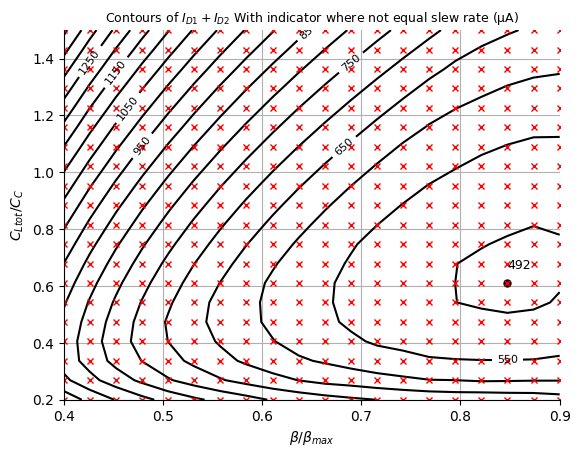

In [33]:
indicator = ID2 < (ID1 * (1+ d['cltot_cc']))

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ With indicator where not equal slew rate (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

for i in range(len(d['beta'])):
    for j in range(len(d['cltot_cc'])):
            if(indicator[i,j]):
                #print(j)
                ax.plot(d['beta'][i]/beta_max, d['cltot_cc'][j], 'x', markersize=4, color='r')
plt.show()


cltot_cc_opt      = 0.6105
beta_opt/beta_max = 0.8474
IDtot_opt = 386.6926


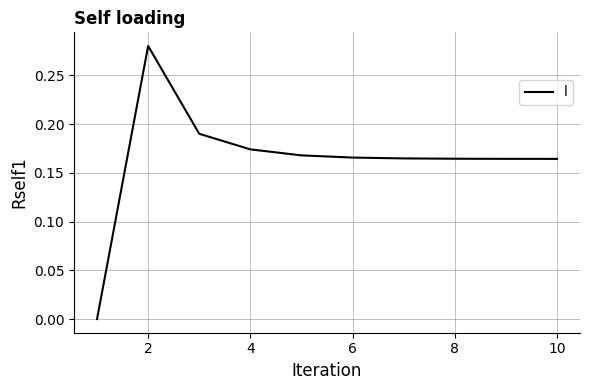

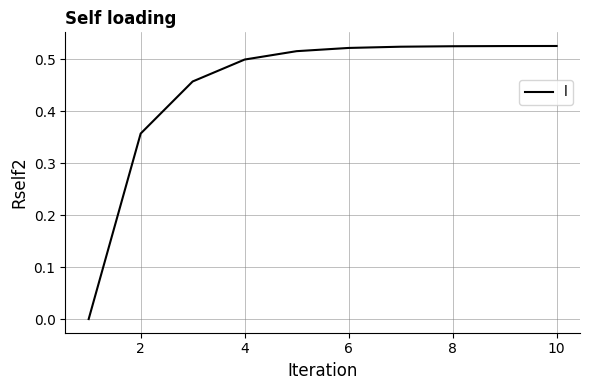

In [34]:
##Self loading loop
d['beta'] = beta_opt
d['cltot_cc'] = cltot_cc_opt
N_iter = 10
rself1 = np.zeros(N_iter)
rself2 = np.zeros(N_iter)

for i in range(N_iter):

    d['rself_1'] = rself1[i]
    d['rself_2'] = rself2[i]
    m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    

    if i+1 < N_iter:
        rself1[i+1] = p['rself1'].item()
        rself2[i+1] = p['rself2'].item()

    # print("i = ", i)
    # print(p['rself1'])
    # print(p['rself2'])


ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
IDtot_opt    = ID_TOT[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc']
beta_opt     = d['beta']

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

xaxis = np.linspace(1,N_iter, N_iter)
adri.coolPlot(xaxis, rself1, "Iteration", "Rself1", "Self loading")
adri.coolPlot(xaxis, rself2, "Iteration", "Rself2", "Self loading")


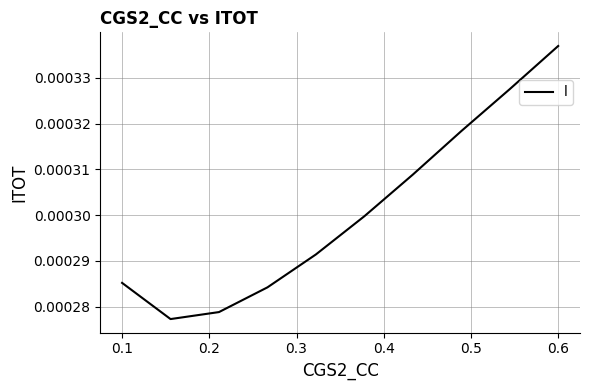

In [6]:
###LOOP CGS_CSS -> Cself
#Design Spec 
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 5e-9,
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.15,
    'L4': 0.15,
    'L2': 0.2,
    'L3': 0.2,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 10),
    'cltot_cc': np.linspace(0.2, 1.5, 10)
    }

cgs2_cc_iter = 10
rself_iter = 5
cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)

rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    #Plots
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]

    # print(f"rself_iter      = {i:.4f}")
    # print(f"cgs2_cc      = {cgs2_cc[k]:.4f}")
    # print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
    # print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
    # print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

adri.coolPlot(CGS2_CC_PLOT, ITOT_PLOT, "CGS2_CC", "ITOT", "CGS2_CC vs ITOT")

In [61]:
###FInal Design
#Design Spec 
##CGS2_CC loop
####Self loading loop
#######test several beta & gm_id to find lowest current point
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 5e-9,
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.15,
    'L4': 0.15,
    'L2': 0.2,
    'L3': 0.2,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 30),
    'cltot_cc': np.linspace(0.2, 1.5, 30)
    }

cgs2_cc_iter = 1
rself_iter = 5
#cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)
cgs2_cc = [0.3]

rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    #Plots
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]

    print(f"rself_iter number of iteration     = {i:.4f}")
    print(f"cgs2_cc      = {cgs2_cc[k]:.4f}")
    print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
    print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
    print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

#final design
d['cltot_cc'] = cltot_cc_opt
d['beta'] = beta_opt
d['rself_1'] = p['rself1'][idx_beta, idx_cl]
d['rself_2'] = p['rself2'][idx_beta, idx_cl]
d['cgs2_cc'] = cgs2_cc

m1,m2,m3,m4,p = two_stage(nmos4, pmos4, s, d)

rself_iter number of iteration     = 4.0000
cgs2_cc      = 0.3000
cltot_cc_opt      = 0.5138
beta_opt/beta_max = 0.8138
IDtot_opt = 287.0748


In [ ]:
def print_design_summary(s, d, m1, m2, m3, m4, p,
                         idx_beta=None, idx_cl=None):
    """
    Print all parameters for:
      - specifications s
      - design choices d
      - operating point p
      - devices m1,m2,m3,m4

    If idx_beta and idx_cl are provided,
    prints the selected optimum point only.
    """

    print("\n" + "="*80)
    print("SPECIFICATIONS : s")
    print("="*80)
    for k, v in s.items():
        print(f"{k:15s} : {v}")

    print("\n" + "="*80)
    print("DESIGN PARAMETERS : d")
    print("="*80)
    for k, v in d.items():
        if np.isscalar(v):
            print(f"{k:15s} : {v}")
        else:
            print(f"{k:15s} : shape={np.shape(v)}")

    # ---------------------------------------------------------
    # helper
    # ---------------------------------------------------------
    def print_block(name, blk):
        print("\n" + "="*80)
        print(name)
        print("="*80)

        for k, v in blk.items():

            # scalar
            if np.isscalar(v):
                print(f"{k:15s} : {v}")

            # array
            else:
                arr = np.asarray(v)

                # print optimum point
                if idx_beta is not None and idx_cl is not None:
                    try:
                        val = arr[idx_beta, idx_cl]
                        print(f"{k:15s} : {val:.4e}")
                    except:
                        print(f"{k:15s} : shape={arr.shape}")

                # print global info
                else:
                    print(
                        f"{k:15s} : "
                        f"shape={arr.shape} | "
                        f"min={np.nanmin(arr):.4e} | "
                        f"max={np.nanmax(arr):.4e}"
                    )

    # ---------------------------------------------------------
    # print all
    # ---------------------------------------------------------
    print_block("M1", m1)
    print_block("M2", m2)
    print_block("M3", m3)
    print_block("M4", m4)
    print_block("P",  p)


print_design_summary(s, d, m1, m2, m3, m4, p)


SPECIFICATIONS : s
G               : 2
FO              : 0.5
fu1             : 219880679.6638283
fp2             : 1319284077.9829698
vod_noise       : 0.0004
L0              : 50
ts              : 5e-09

DESIGN PARAMETERS : d
L1              : 0.15
L4              : 0.15
L2              : 0.2
L3              : 0.2
gam1            : 0.8
gam4            : 0.8
gam2            : 0.8
gam3            : 0.8
gm3_gm1         : 1.0
gm4_gm2         : 0.5
cgs2_cc         : shape=(1,)
rself_1         : 0.4999661359287362
rself_2         : 0.24167801448529047
beta            : 0.271264367816092
cltot_cc        : 0.5137931034482759

M1
W               : shape=(1, 1) | min=4.5913e+01 | max=4.5913e+01
gm              : shape=(1, 1) | min=2.3609e-03 | max=2.3609e-03
gmid            : shape=(1, 1) | min=1.4828e+01 | max=1.4828e+01
cgg             : shape=(1, 1) | min=6.8389e-14 | max=6.8389e-14
cgd             : shape=(1, 1) | min=1.6150e-14 | max=1.6150e-14
cdd             : shape=(1, 1) | min=2.7793e

C:\Users\Surfe\AppData\Local\Temp\ipykernel_65392\1234277420.py:60: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(arr):.4e} | "
C:\Users\Surfe\AppData\Local\Temp\ipykernel_65392\1234277420.py:61: RuntimeWarning: All-NaN slice encountered
  f"max={np.nanmax(arr):.4e}"


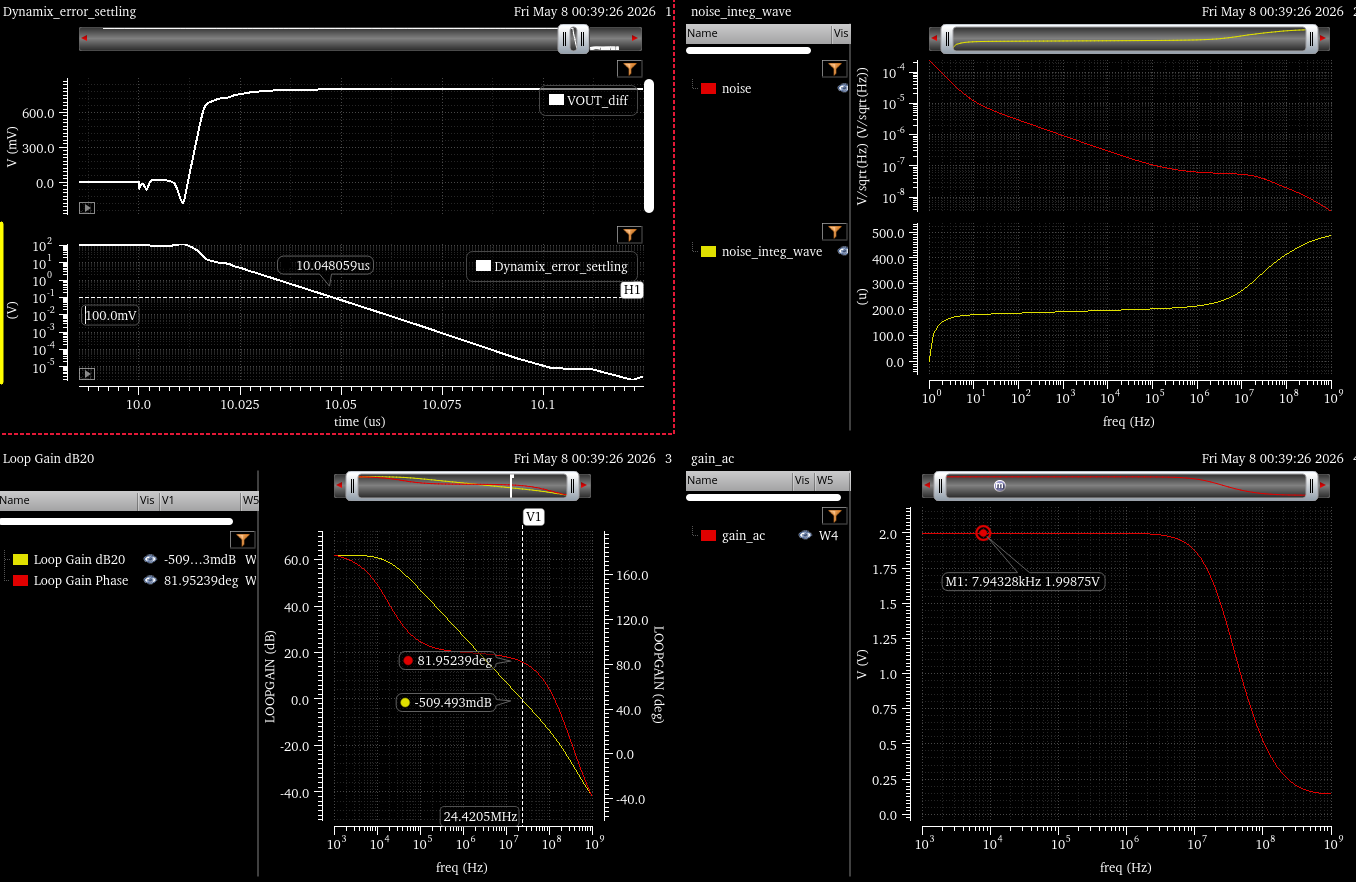  
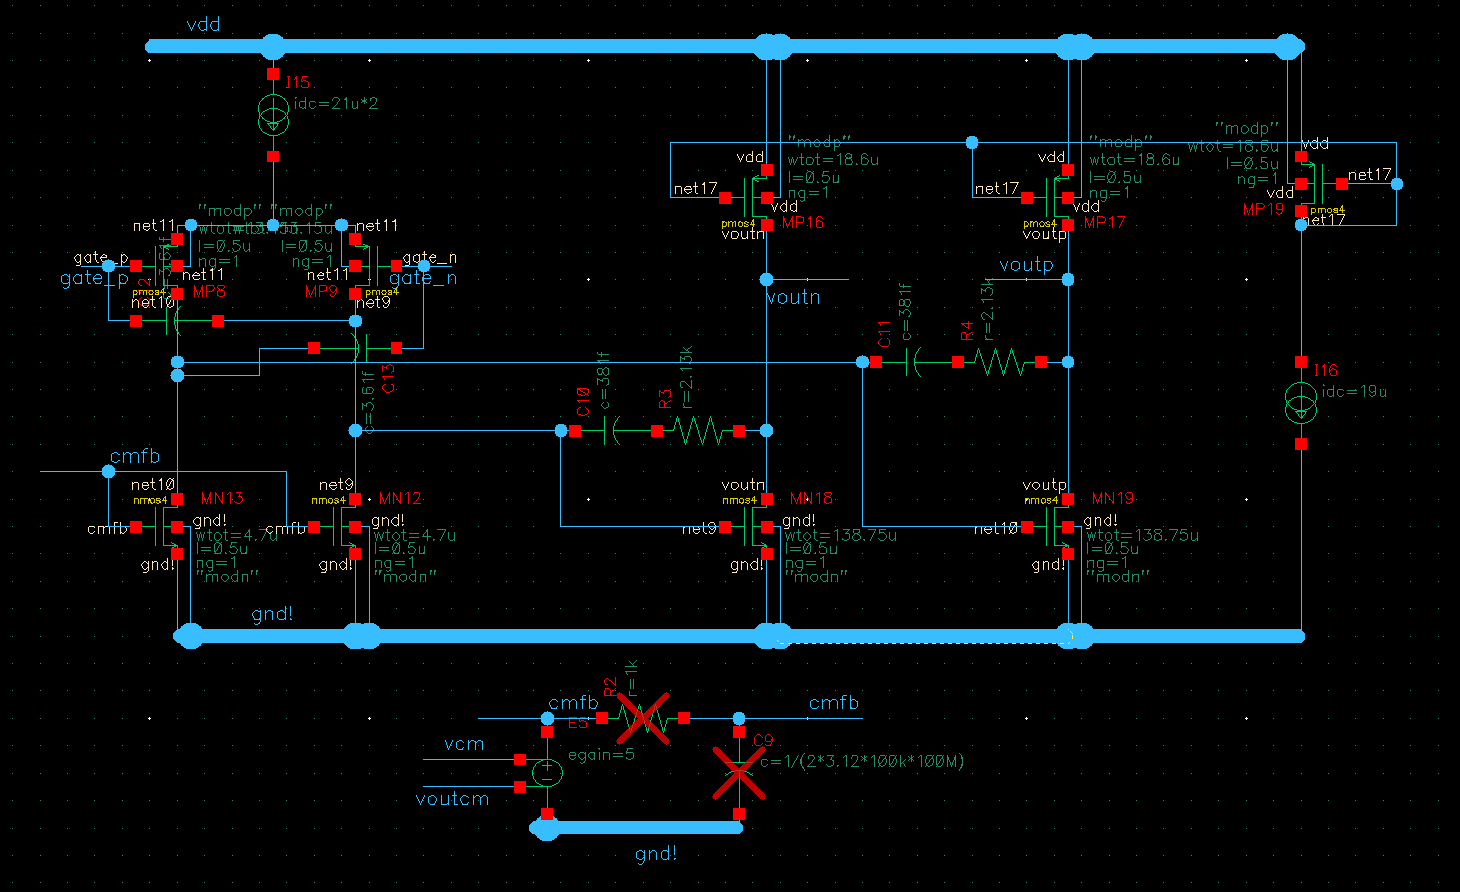  
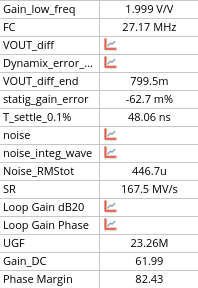

cltot_cc_opt      = 0.4737
GMID_opt      = 19.0000
beta_opt/beta_max = 0.8474
IDtot_opt = 287.2588


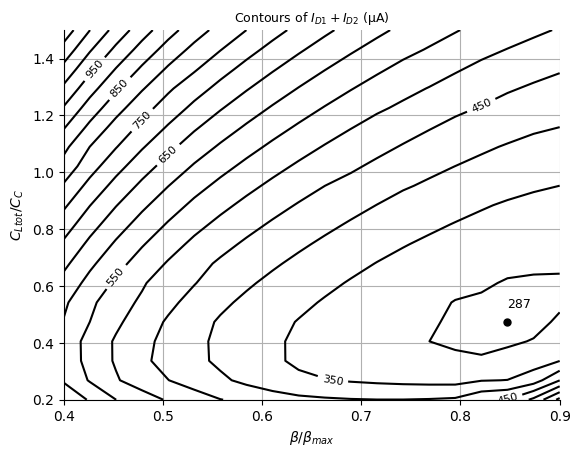

In [82]:
#Design Spec 
##Opti with slew rate
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 5e-9,
    'vod_final' : 400e-3,
    'ed'    : 0.1/100
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.15,
    'L4': 0.15,
    'L2': 0.2,
    'L3': 0.2,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 20),
    'cltot_cc': np.linspace(0.2, 1.5, 20),
    'gm_id_test': np.linspace(1, 30, 30),
    }


def two_stage_sr_opti(nmos, pmos, s, d):
    kBT = 1.3806488e-23 * 300
    beta_arr     = np.atleast_1d(d['beta'])
    cltot_cc_arr = np.atleast_1d(d['cltot_cc'])
    N = len(beta_arr)   # axe 0
    M = len(cltot_cc_arr)  # axe 1
    m1 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id']}
    m2 = {k: np.full((N, M), np.nan) for k in ['W','gm','gmid','cgg','cgd','cdd','ft','id','cgs','fts']}
    m3 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    m4 = {k: np.full((N, M), np.nan) for k in ['W','gmid','cdd']}
    p  = {k: np.full((N, M), np.nan) for k in ['cc','cltot','cf','cs','cl','c1','rz','cn','rself1','rself2','cc_add']}
    m1['L'] = d['L1']
    m2['L'] = d['L2']
    m3['L'] = d['L3']
    m4['L'] = d['L4']

    for j, beta in enumerate(beta_arr):  # j = indice beta → ligne [j,:]
        cc    = (2/beta * kBT * d['gam1'] * (1 + d['gam3']/d['gam1'] * d['gm3_gm1'])
               + 1/cltot_cc_arr * kBT * (1 + d['gam2'] * (1 + d['gam4']/d['gam2'] * d['gm4_gm2']))
               ) / s['vod_noise']**2
        cltot = cc * cltot_cc_arr
        cf    = cltot / (1 + d['rself_2']) / (1 - beta + s['FO'] * s['G'])
        cs    = cf * s['G']
        cl    = cs * s['FO']
        cgs2  = cc * d['cgs2_cc']
        c1    = cgs2 * (1 + d['rself_1'])
        gmR    = np.sqrt(s['L0']) / beta

        ######ADD for loop for gm_id for opti slew rate

        gm_id_test = d['gm_id_test'] 
        N_iter_gm_id_test = len(d['gm_id_test'])

        X = np.zeros((N_iter_gm_id_test,M))
    
        wu1 = np.zeros((N_iter_gm_id_test,M))
        gm1 = np.zeros((N_iter_gm_id_test,M))
        cgg1 = np.zeros((N_iter_gm_id_test,M))
        ft1 = np.zeros((N_iter_gm_id_test,M))
        #gmid1 = np.zeros((N_iter_gm_id_test,M))
        id1 = np.zeros((N_iter_gm_id_test,M))
        cgs1 = np.zeros((N_iter_gm_id_test,M))
        cin = np.zeros((N_iter_gm_id_test,M))
        beta_actual = np.zeros((N_iter_gm_id_test,M))

        for k in range(len(gm_id_test)):
            
            X[k,:] = s['vod_final'] * beta / 2 * gm_id_test[k]
            X[k, X[k,:] < 1] = 1
            wu1[k,:] = 1 / s['ts']*(X[k,:] - 1 + np.log(X[k,:] * 1/s['ed']))
            gm1[k,:]    = (wu1[k,:] * cc / beta * (1 + (1 + c1/cc) / gmR + (1 + cltot/cc) / gmR))
            cgg1[k,:]  =  pmos.lookup('CGG_GM', GM_ID=gm_id_test[k], L=d['L1'], WARNING=False) * gm1[k,:]
            cgs1[k,:]  =  pmos.lookup('CGS_GM', GM_ID=gm_id_test[k], L=d['L1'], WARNING=False) * gm1[k,:]
            #cgg1[k,:]   = cf * (1/beta - 1 - s['G'])
            ft1[k,:]    = gm1[k,:] / (2*np.pi * cgg1[k,:])
            #gmid1[k,:]  = pmos.lookup('GM_ID', GM_CGG=2*np.pi*ft1[k,:], L=d['L1'], WARNING=False)
            id1[k,:]    = gm1[k,:] / gm_id_test[k]
            ##Compute input cap for real beta
            #cgs1[k,:] = cgg1[k,:]#gm1[k,:] / (gm1[k] / cgg1[k])
            cin[k,:] = cgs1[k,:]
            beta_actual[k,:] = cf / (cf + cs + cin[k,:])

        #Take closest point to beta, thorw away others
        index_min_gmid = np.argmin(np.abs(beta_actual - beta), axis=0)

        cols = np.arange(M)

        X       = X[index_min_gmid, cols]
        wu1     = wu1[index_min_gmid, cols]
        gm1     = gm1[index_min_gmid, cols]
        cgg1    = cgg1[index_min_gmid, cols]
        ft1     = ft1[index_min_gmid, cols]
        gmid1   = gm_id_test[index_min_gmid]
        id1     = id1[index_min_gmid, cols]
        cgs1    = cgs1[index_min_gmid, cols]
        cin     = cin[index_min_gmid, cols]

        slew_pct = (X - 1) / (X - 1 + np.log(X / s['ed']))
        #print(slew_pct)
        #######Compute actaul beta, find closest to beta, store only this value



        gm2    = 2*np.pi * s['fp2'] * c1 * (1 + cltot/cc + cltot/c1)
        fts2   = gm2 / (2*np.pi * cgs2)
        gmid2  = nmos.lookup('GM_ID', GM_CGS=2*np.pi*fts2, L=d['L2'], WARNING=False)
        id2    = gm2 / gmid2


        # Storage [j,:] → ligne j = beta j, colonnes = tous les cltot_cc
        p['cc'][j,:]     = cc
        p['cltot'][j,:]  = cltot
        p['cf'][j,:]     = cf
        p['cs'][j,:]     = cs
        p['cl'][j,:]     = cl
        p['c1'][j,:]     = c1
        m2['cgs'][j,:]   = cgs2
        m1['gm'][j,:]    = gm1
        m1['cgg'][j,:]   = cgg1
        m1['ft'][j,:]    = ft1
        m1['gmid'][j,:]  = gmid1
        m1['id'][j,:]    = id1
        m2['gm'][j,:]    = gm2
        m2['fts'][j,:]   = fts2
        m2['gmid'][j,:]  = gmid2
        m2['id'][j,:]    = id2
        p['rz'][j,:]     = 1 / gm2

        m3['gmid'][j,:]  = gmid1 * d['gm3_gm1']
        m4['gmid'][j,:]  = gmid2 * d['gm4_gm2']
        m1['W'][j,:]     = id1 / pmos.lookup('ID_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['W'][j,:]     = id2 / nmos.lookup('ID_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['W'][j,:]     = id1 / nmos.lookup('ID_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['W'][j,:]     = id2 / pmos.lookup('ID_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        m1['cgd'][j,:]   = m1['W'][j,:] * pmos.lookup('CGD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        p['cn'][j,:]     = m1['cgd'][j,:]
        m2['cgd'][j,:]   = m2['W'][j,:] * nmos.lookup('CGD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        p['cc_add'][j,:] = cc - m2['cgd'][j,:]

        m1['cdd'][j,:]   = m1['W'][j,:] * pmos.lookup('CDD_W', GM_ID=gmid1, L=d['L1'], WARNING=False)
        m2['cdd'][j,:]   = m2['W'][j,:] * nmos.lookup('CDD_W', GM_ID=gmid2, L=d['L2'], WARNING=False)
        m3['cdd'][j,:]   = m3['W'][j,:] * nmos.lookup('CDD_W', GM_ID=m3['gmid'][j,:], L=d['L3'], WARNING=False)
        m4['cdd'][j,:]   = m4['W'][j,:] * pmos.lookup('CDD_W', GM_ID=m4['gmid'][j,:], L=d['L4'], WARNING=False)

        p['rself1'][j,:] = (m1['cdd'][j,:] + m3['cdd'][j,:]) / m2['cgs'][j,:]
        p['rself2'][j,:] = ((m2['cdd'][j,:] - m2['cgd'][j,:]) + m4['cdd'][j,:]) / (cl + (1 - beta) * cf)

    return m1, m2, m3, m4, p


m1,m2,m3,m4,p = two_stage_sr_opti(nmos4, pmos4, s, d)

ID1 = m1['id']
ID2 = m2['id']
GMID1 = m1['gmid']
GMID2 = m2['gmid']

ID_TOT = ID1 + ID2

idx = np.nanargmin(ID_TOT)

idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)

IDtot_opt    = ID_TOT[idx_beta, idx_cl]
GMID_opt    = GMID1[idx_beta, idx_cl]
cltot_cc_opt = d['cltot_cc'][idx_cl]
beta_opt     = d['beta'][idx_beta]

print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
print(f"GMID_opt      = {GMID_opt:.4f}")
print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")

# ── Contour plot ─────────────────────────────────────────────────
# ID_TOT est (N_beta, M_cltot) → transpose pour contour(x=beta, y=cltot_cc)
fig, ax = plt.subplots()
cs = ax.contour(d['beta']/beta_max, d['cltot_cc'], ID_TOT.T * 1e6, levels=20, colors='k')
ax.clabel(cs, cs.levels[::2], inline=True, fmt='%d', fontsize=8)
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel(r'$C_{Ltot}/C_C$')
ax.set_title(r'Contours of $I_{D1}+I_{D2}$ (µA)', fontsize=9, fontweight='normal')

ax.plot(beta_opt/beta_max, cltot_cc_opt, 'ko', markersize=5)
ax.text(beta_opt/beta_max, cltot_cc_opt + 0.05, f'{IDtot_opt*1e6:.0f}', fontsize=9)

plt.show()



##Final Opti script : Slew_rate, self loading, cgs2_cc 

In [143]:
###FInal Design
#Design Spec 
##CGS2_CC loop
####Self loading loop
#######test several beta & gm_id to find lowest current point
#=> Take point with lowest current for CGS2_CC
s = {
    'G'         : 2,
    'FO'        : 0.5,
    'fu1'       : 0,
    'fp2'       : 0,
    'vod_noise' : 400e-6,
    'L0' : 50,
    'ts' : 5e-9,
    'vod_final' : 400e-3,
    'ed'    : 0.1/100
}
beta_max = 1 / (1 + s['G'])
s['fu1'] = 1/(2*np.pi) * np.log(1/ (0.1/100)) / s['ts']
s['fp2'] = s['fu1'] * 6.0

# Constants for another design
d = {
    'L1': 0.15,
    'L4': 0.15,
    'L2': 0.2,
    'L3': 0.2,
    'gam1': 0.8,
    'gam4': 0.8,
    'gam2': 0.8,
    'gam3': 0.8,
    'gm3_gm1': 1.0,
    'gm4_gm2': 0.5,
    'cgs2_cc': 0.5,
    'rself_1': 0,
    'rself_2': 0,
    'beta': beta_max * np.linspace(0.4, 0.9, 10),
    'cltot_cc': np.linspace(0.2, 1.5, 10),
    'gm_id_test': np.linspace(1, 30,15),
    }

cgs2_cc_iter = 8
rself_iter = 4
cgs2_cc = np.linspace(0.1,0.6,cgs2_cc_iter)
#cgs2_cc = [0.3]

rself1 = np.zeros(rself_iter)
rself2 = np.zeros(rself_iter)
rself1_out = np.zeros(rself_iter)
rself2_out = np.zeros(rself_iter)

ITOT_PLOT = np.zeros(cgs2_cc_iter)
CGS2_CC_PLOT = np.zeros(cgs2_cc_iter)
cltot_cc_PLOT = np.zeros(cgs2_cc_iter)
beta_opt_PLOT = np.zeros(cgs2_cc_iter)
GMID_opt_PLOT = np.zeros(cgs2_cc_iter)
rself1_opt_PLOT = np.zeros(cgs2_cc_iter)
rself2_opt_PLOT = np.zeros(cgs2_cc_iter)

for k in range(len(cgs2_cc)):
    d['cgs2_cc'] = cgs2_cc[k]
    for i in range(rself_iter):
        d['rself_1'] = rself1[i]
        d['rself_2'] = rself2[i]
        m1,m2,m3,m4,p = two_stage_sr_opti(nmos4, pmos4, s, d)
    
    #print(p['rself1'])
    ID1 = m1['id']
    ID2 = m2['id']
    ID_TOT = ID1 + ID2
    idx = np.nanargmin(ID_TOT)
    idx_beta, idx_cl = np.unravel_index(idx, ID_TOT.shape)
    IDtot_opt    = ID_TOT[idx_beta, idx_cl]
    cltot_cc_opt = d['cltot_cc'][idx_cl]
    beta_opt     = d['beta'][idx_beta]
    GMID_opt    = GMID1[idx_beta, idx_cl]
    #Plots / cgs_2_cc opti
    ITOT_PLOT[k] = IDtot_opt
    CGS2_CC_PLOT[k] = cgs2_cc[k]
    cltot_cc_PLOT[k] = cltot_cc_opt
    beta_opt_PLOT[k] = beta_opt
    GMID_opt_PLOT[k] = GMID_opt
    rself1_opt_PLOT[k] = p['rself1'][idx_beta, idx_cl]
    rself2_opt_PLOT[k] = p['rself2'][idx_beta, idx_cl]

    # print(f"rself_iter number of iteration     = {i:.4f}")
    # print(f"cgs2_cc      = {cgs2_cc[k]:.4f}")
    # print(f"cltot_cc_opt      = {cltot_cc_opt:.4f}")
    # print(f"beta_opt/beta_max = {beta_opt/beta_max:.4f}")
    # print(f"IDtot_opt = {IDtot_opt*1e6:.4f}")
    # print(f"GMID_opt      = {GMID_opt:.4f}")

idx_min_cgs2_cc_loop = np.argmin(ITOT_PLOT)
#final design
###Take point where current is minimized for cgs2/cc
d['cltot_cc'] = cltot_cc_PLOT[idx_min_cgs2_cc_loop]
d['beta'] = beta_opt_PLOT[idx_min_cgs2_cc_loop]
d['cgs2_cc'] = CGS2_CC_PLOT[idx_min_cgs2_cc_loop]
d['gm_id_test'] = np.unique(GMID_opt_PLOT[idx_min_cgs2_cc_loop])
d['rself_1'] = rself1_opt_PLOT[idx_min_cgs2_cc_loop]
d['rself_2'] = rself2_opt_PLOT[idx_min_cgs2_cc_loop]

m1,m2,m3,m4,p = two_stage_sr_opti(nmos4, pmos4, s, d)



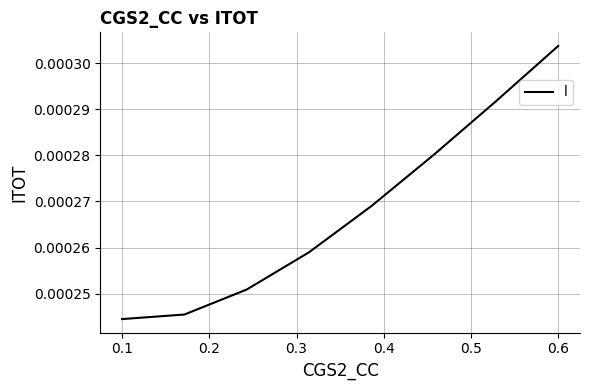

np.float64(0.1)

In [147]:
adri.coolPlot(CGS2_CC_PLOT, ITOT_PLOT, "CGS2_CC", "ITOT", "CGS2_CC vs ITOT")
CGS2_CC_PLOT[idx_min_cgs2_cc_loop]

In [148]:
def print_design_summary(s, d, m1, m2, m3, m4, p,
                         idx_beta=None, idx_cl=None):
    """
    Print all parameters for:
      - specifications s
      - design choices d
      - operating point p
      - devices m1,m2,m3,m4

    If idx_beta and idx_cl are provided,
    prints the selected optimum point only.
    """

    print("\n" + "="*80)
    print("SPECIFICATIONS : s")
    print("="*80)
    for k, v in s.items():
        print(f"{k:15s} : {v}")

    print("\n" + "="*80)
    print("DESIGN PARAMETERS : d")
    print("="*80)
    for k, v in d.items():
        if np.isscalar(v):
            print(f"{k:15s} : {v}")
        else:
            print(f"{k:15s} : shape={np.shape(v)}")

    # ---------------------------------------------------------
    # helper
    # ---------------------------------------------------------
    def print_block(name, blk):
        print("\n" + "="*80)
        print(name)
        print("="*80)

        for k, v in blk.items():

            # scalar
            if np.isscalar(v):
                print(f"{k:15s} : {v}")

            # array
            else:
                arr = np.asarray(v)

                # print optimum point
                if idx_beta is not None and idx_cl is not None:
                    try:
                        val = arr[idx_beta, idx_cl]
                        print(f"{k:15s} : {val:.4e}")
                    except:
                        print(f"{k:15s} : shape={arr.shape}")

                # print global info
                else:
                    print(
                        f"{k:15s} : "
                        f"shape={arr.shape} | "
                        f"min={np.nanmin(arr):.4e} | "
                        f"max={np.nanmax(arr):.4e}"
                    )

    # ---------------------------------------------------------
    # print all
    # ---------------------------------------------------------
    print_block("M1", m1)
    print_block("M2", m2)
    print_block("M3", m3)
    print_block("M4", m4)
    print_block("P",  p)


print_design_summary(s, d, m1, m2, m3, m4, p)


SPECIFICATIONS : s
G               : 2
FO              : 0.5
fu1             : 219880679.6638283
fp2             : 1319284077.9829698
vod_noise       : 0.0004
L0              : 50
ts              : 5e-09
vod_final       : 0.4
ed              : 0.001

DESIGN PARAMETERS : d
L1              : 0.15
L4              : 0.15
L2              : 0.2
L3              : 0.2
gam1            : 0.8
gam4            : 0.8
gam2            : 0.8
gam3            : 0.8
gm3_gm1         : 1.0
gm4_gm2         : 0.5
cgs2_cc         : 0.1
rself_1         : 2.212002219576514
rself_2         : 0.10755699344694843
beta            : 0.26296296296296295
cltot_cc        : 0.34444444444444444
gm_id_test      : shape=(1,)

M1
W               : shape=(1, 1) | min=1.7886e+02 | max=1.7886e+02
gm              : shape=(1, 1) | min=2.9345e-03 | max=2.9345e-03
gmid            : shape=(1, 1) | min=2.3000e+01 | max=2.3000e+01
cgg             : shape=(1, 1) | min=2.1956e-13 | max=2.1956e-13
cgd             : shape=(1, 1) | min=6.

C:\Users\Surfe\AppData\Local\Temp\ipykernel_65392\1234277420.py:60: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(arr):.4e} | "
C:\Users\Surfe\AppData\Local\Temp\ipykernel_65392\1234277420.py:61: RuntimeWarning: All-NaN slice encountered
  f"max={np.nanmax(arr):.4e}"
